In [ ]:
import os
import json
from typing import Dict, List, Tuple
import getpass

import evaluate
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from datasets import Dataset
from pymilvus import CollectionSchema, DataType, FieldSchema, MilvusClient
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer

# OpenAI API Key Setup
if not os.environ.get("OPENAI_API_KEY"):
    api_key = getpass.getpass("Enter your OpenAI API Key: ")
    # Clean the key: remove quotes, spaces, newlines
    api_key = api_key.strip().strip("'").strip('"').strip()
    os.environ["OPENAI_API_KEY"] = api_key


sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True})

SQUAD_METRIC = evaluate.load("squad")

In [2]:
PASSAGES_PATH = "hf://datasets/rag-datasets/rag-mini-wikipedia/data/passages.parquet/part.0.parquet"
QUERIES_PATH = "hf://datasets/rag-datasets/rag-mini-wikipedia/data/test.parquet/part.0.parquet"
COLLECTION_NAME = "rag_mini"
MILVUS_PATH = "rag_wikipedia_mini.db"
CONTEXT_SEPARATOR = """

---

"""

def load_text_table(path: str, text_column: str) -> pd.DataFrame:
    """Load a parquet table, drop empty rows, and reset the index."""
    df = pd.read_parquet(path)
    df = df.dropna(subset=[text_column])
    df[text_column] = df[text_column].astype(str).str.strip()
    df = df[df[text_column] != ""]
    return df.reset_index(drop=True)

def load_queries(path: str) -> pd.DataFrame:
    """Load queries with answers and ensure both fields are non-empty strings."""
    df = pd.read_parquet(path)
    df = df.dropna(subset=["question", "answer"])
    df["question"] = df["question"].astype(str).str.strip()
    df["answer"] = df["answer"].astype(str).str.strip()
    df = df[(df["question"] != "") & (df["answer"] != "")]
    return df.reset_index(drop=True)

def compute_length_summary(df: pd.DataFrame, column: str) -> Tuple[pd.Series, pd.Series]:
    lengths = df[column].str.len()
    summary = lengths.describe().round(2)
    return lengths, summary

def plot_length_diagnostics(lengths: pd.Series, bins: int = 80) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.histplot(lengths, bins=bins, ax=axes[0], kde=True, color="#4C78A8")
    axes[0].set_title("Passage Length Distribution")
    axes[0].set_xlabel("Characters")
    sns.boxplot(x=lengths, ax=axes[1], color="#F58518")
    axes[1].set_title("Passage Length Boxplot")
    axes[1].set_xlabel("Characters")
    plt.tight_layout()
    plt.show()

def display_passage_extremes(df: pd.DataFrame, column: str, count: int = 1) -> None:
    ranked = df.assign(length=df[column].str.len()).sort_values("length", ascending=True)
    for label, sample in (("Shortest", ranked.head(count)), ("Longest", ranked.tail(count))):
        for _, row in sample.iterrows():
            print(f"{label} passage (length={row['length']}):")
            print(row[column][:400])
            print("---")

def summarize_text_table(df: pd.DataFrame, text_column: str, label=None, extra_categorical_columns=None) -> pd.DataFrame:
    extra_categorical_columns = list(extra_categorical_columns or [])
    if df.empty:
        return pd.DataFrame([{"metric": "rows", "value": 0}])
    lengths = df[text_column].str.len()
    summary_rows = [
        {"metric": "label", "value": label or text_column},
        {"metric": "rows", "value": f"{len(df):,}"},
        {"metric": "columns", "value": ", ".join(df.columns)},
        {"metric": "avg_length_chars", "value": f"{lengths.mean():.2f}"},
        {"metric": "median_length_chars", "value": f"{lengths.median():.0f}"},
        {"metric": "min_length_chars", "value": int(lengths.min())},
        {"metric": "max_length_chars", "value": int(lengths.max())},
        {"metric": "std_length_chars", "value": f"{lengths.std(ddof=0):.2f}"},
        {"metric": "duplicate_text_entries", "value": f"{df.duplicated(subset=[text_column]).sum():,}"},
    ]
    for column in extra_categorical_columns:
        if column in df.columns:
            summary_rows.append({"metric": f"unique_{column}", "value": f"{df[column].nunique():,}"})
    return pd.DataFrame(summary_rows)


def derive_text_quality_notes(df: pd.DataFrame, text_column: str) -> List[str]:
    if df.empty:
        return ["Dataset is empty after preprocessing; check data loading steps."]
    notes: List[str] = []
    lengths = df[text_column].str.len()
    empties = int((lengths == 0).sum())
    duplicates = int(df.duplicated(subset=[text_column]).sum())
    notes.append(f"Length distribution spans {int(lengths.min())}-{int(lengths.max())} characters with median {int(lengths.median())}.")
    notes.append(f"5th to 95th percentile ranges from {int(lengths.quantile(0.05))} to {int(lengths.quantile(0.95))} characters.")
    if empties:
        notes.append(f"Detected {empties:,} empty entries post-cleaning; consider additional filtering.")
    else:
        notes.append("No empty records detected after cleaning.")
    if duplicates:
        notes.append(f"Found {duplicates:,} duplicate text entries; deduplication may be beneficial.")
    else:
        notes.append("No duplicate text entries detected in the current split.")
    return notes


def ensure_results_dir():
    from pathlib import Path
    cwd = Path.cwd().resolve()
    candidates = [cwd / 'results', cwd.parent / 'results']
    for candidate in candidates:
        if candidate.exists():
            candidate.mkdir(parents=True, exist_ok=True)
            return candidate
    fallback = candidates[0]
    fallback.mkdir(parents=True, exist_ok=True)
    return fallback


def persist_json(payload: Dict, filename: str):
    import json
    output_path = ensure_results_dir() / filename
    with output_path.open('w', encoding='utf-8') as fh:
        json.dump(payload, fh, indent=2)
    return output_path


def persist_dataframe(df: pd.DataFrame, filename: str):
    output_path = ensure_results_dir() / filename
    df.to_csv(output_path, index=False)
    return output_path

## Step 1 · Setup and Data Exploration

Environment diagnostics, dataset profiling, and quality analysis.

In [3]:
import torch

def collect_environment_diagnostics(package_names) -> pd.DataFrame:
    from importlib import metadata
    import platform
    diagnostics = [
        {"component": "python", "version": platform.python_version()},
        {"component": "torch cuda available", "version": str(torch.cuda.is_available())},
        {"component": "torch device count", "version": str(torch.cuda.device_count())},
    ]
    for name in package_names:
        try:
            version = metadata.version(name)
        except metadata.PackageNotFoundError:
            version = "not installed"
        diagnostics.append({"component": name, "version": version})
    return pd.DataFrame(diagnostics)

ENVIRONMENT_PACKAGES = [
    "pymilvus",
    "sentence-transformers",
    "transformers",
    "ragas",
    "langchain-openai",
    "evaluate",
    "datasets",
]

environment_diagnostics = collect_environment_diagnostics(ENVIRONMENT_PACKAGES)
environment_diagnostics


,component,version
0,python,3.12.8
1,torch cuda available,False
2,torch device count,0
3,pymilvus,2.6.2
4,sentence-transformers,5.1.1
5,transformers,4.56.2
6,ragas,0.3.5
7,langchain-openai,0.3.34
8,evaluate,0.4.6
9,datasets,4.1.1


## Load and clean passages

Read the corpus and drop rows that are empty or NA.


In [4]:
passages = load_text_table(PASSAGES_PATH, "passage")
print(f"Loaded {len(passages):,} passages.")
passages.head()


Loaded 3,200 passages.


,passage
0,"Uruguay (official full name in ; pron. , Eas..."
1,"It is bordered by Brazil to the north, by Arge..."
2,Montevideo was founded by the Spanish in the e...
3,The economy is largely based in agriculture (m...
4,"According to Transparency International, Urugu..."


In [5]:
passage_extra_fields = [column for column in ("title", "section", "doc_id", "document_id") if column in passages.columns]
passage_profile_df = summarize_text_table(passages, "passage", label="passages", extra_categorical_columns=passage_extra_fields)
passage_profile_df

,metric,value
0,label,passages
1,rows,"3,200"
2,columns,passage
3,avg_length_chars,389.71
4,median_length_chars,299
5,min_length_chars,1
6,max_length_chars,2515
7,std_length_chars,348.35
8,duplicate_text_entries,7


In [6]:
print("Passage data quality notes:")
for note in derive_text_quality_notes(passages, "passage"):
    print(f"- {note}")

Passage data quality notes:
- Length distribution spans 1-2515 characters with median 299.
- 5th to 95th percentile ranges from 26 to 1061 characters.
- No empty records detected after cleaning.
- Found 7 duplicate text entries; deduplication may be beneficial.


## Passage-length EDA

Profile passage length (min, max, distribution) before indexing.


In [7]:
passage_lengths, passage_summary = compute_length_summary(passages, "passage")
print("Passage length summary (characters):")
print(passage_summary)


Passage length summary (characters):
count    3200.00
mean      389.71
std       348.40
min         1.00
25%       107.75
50%       299.00
75%       574.00
max      2515.00
Name: passage, dtype: float64


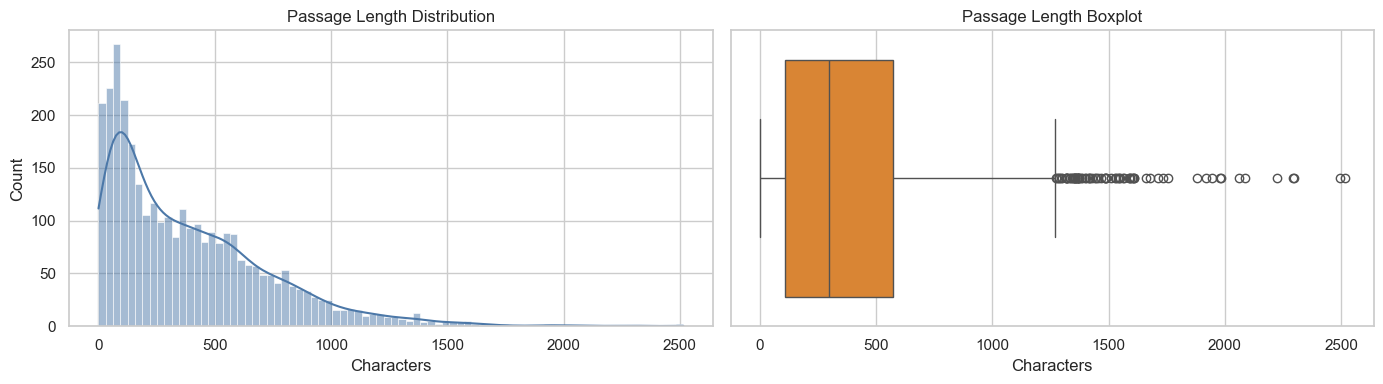

In [8]:
plot_length_diagnostics(passage_lengths, bins=80)


In [9]:
display_passage_extremes(passages, "passage")


Shortest passage (length=1):
}
---
Longest passage (length=2515):
As Ford approached his ninetieth year, he began to experience significant health problems associated with old age. He suffered two minor strokes at the 2000 Republican National Convention, but made a quick recovery.  Gerald Ford recovering after strokes. BBC, August 2, 2000.  Retrieved on December 31, 2006.  In January 2006, he spent 11 days at the Eisenhower Medical Center near his residence at R
---


# Tokenize Text and Generate Embeddings using Sentence Transformers

## Step 2 · Naive RAG Implementation

Build the baseline RAG system with embedding generation, Milvus vector database, retrieval, and FLAN-T5 generation.

In [10]:
EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"
embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)
print(
    f"Loaded embedding model '{EMBEDDING_MODEL_NAME}' "
    f"with dimension {embedding_model.get_sentence_embedding_dimension()}."
)


Loaded embedding model 'all-MiniLM-L6-v2' with dimension 384.


In [11]:
passages = passages.reset_index(drop=True)
embeddings = embedding_model.encode(
    passages["passage"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
)
print(f"Computed passage embeddings with shape {embeddings.shape}.")


Batches:   0%|          | 0/50 [00:00<?, ?it/s]

Computed passage embeddings with shape (3200, 384).


## Create the Milvus client and insert embeddings

Define a collection schema (`id`, passage text, `embedding`) and insert the embedded passages.


In [12]:
id_field = FieldSchema(name="id", dtype=DataType.INT64, is_primary=True, auto_id=False)
passage_field = FieldSchema(name="passage", dtype=DataType.VARCHAR, max_length=5000)
embedding_field = FieldSchema(
    name="embedding",
    dtype=DataType.FLOAT_VECTOR,
    dim=int(embeddings.shape[1]),
)


In [13]:
collection_schema = CollectionSchema(
    fields=[id_field, passage_field, embedding_field],
    description="RAG Mini Wikipedia passages",
    enable_dynamic_field=False,
)


In [14]:
client = MilvusClient(MILVUS_PATH)

def ensure_collection(client: MilvusClient, name: str, schema: CollectionSchema) -> None:
    if client.has_collection(collection_name=name):
        client.drop_collection(collection_name=name)
        print(f"Dropped existing collection: {name}")
    client.create_collection(collection_name=name, schema=schema)
    print(f"Created collection: {name}")

ensure_collection(client, COLLECTION_NAME, collection_schema)


/path/to/rag-eval/.venv/lib/python3.12/site-packages/milvus_lite/__init__.py:15: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Dropped existing collection: rag_mini
Created collection: rag_mini


**Convert the DataFrame to a list of records.** Each record carries three keys: `id`, `passage`, `embedding`.


In [15]:
passages["embedding"] = embeddings.tolist()


In [16]:
rag_data = (
    passages.reset_index()
    .rename(columns={"index": "id"})
    [["id", "passage", "embedding"]]
    .to_dict("records")
)
print(f"Prepared {len(rag_data):,} records for Milvus ingestion.")


Prepared 3,200 records for Milvus ingestion.


In [17]:
sample_record = rag_data[0]
print(f"id: {sample_record['id']}")
print(f"passage preview: {sample_record['passage'][:200]}...")
print(f"embedding dimension: {len(sample_record['embedding'])}")


id: 0
passage preview: Uruguay (official full name in  ; pron.  , Eastern Republic of  Uruguay) is a country located in the southeastern part of South America.  It is home to 3.3 million people, of which 1.7 million live in...
embedding dimension: 384


In [18]:
insert_result = client.insert(collection_name=COLLECTION_NAME, data=rag_data)
inserted_count = getattr(insert_result, "insert_count", len(rag_data))
print(f"Inserted approximately {inserted_count:,} vectors into '{COLLECTION_NAME}'.")


Inserted approximately 3,200 vectors into 'rag_mini'.


Sanity-check the database.


In [19]:
collection_stats = client.get_collection_stats(COLLECTION_NAME)
print(f"Entity count: {collection_stats['row_count']}")
print("Collection schema:", client.describe_collection(COLLECTION_NAME))


Entity count: 3200
Collection schema: {'collection_name': 'rag_mini', 'auto_id': False, 'num_shards': 0, 'description': 'RAG Mini Wikipedia passages', 'fields': [{'field_id': 100, 'name': 'id', 'description': '', 'type': <DataType.INT64: 5>, 'params': {}, 'is_primary': True}, {'field_id': 101, 'name': 'passage', 'description': '', 'type': <DataType.VARCHAR: 21>, 'params': {'max_length': 5000}}, {'field_id': 102, 'name': 'embedding', 'description': '', 'type': <DataType.FLOAT_VECTOR: 101>, 'params': {'dim': 384}}], 'functions': [], 'aliases': [], 'collection_id': 0, 'consistency_level': 0, 'properties': {}, 'num_partitions': 0, 'enable_dynamic_field': False}


## Retrieve results

Read and clean the question set, embed each query with the passage embedding model, build the search index, and fetch the top-N passages per query.


In [20]:
queries = load_queries(QUERIES_PATH)
print(f"Loaded {len(queries):,} evaluation queries.")
queries.head()


Loaded 918 evaluation queries.


,question,answer
0,Was Abraham Lincoln the sixteenth President of...,yes
1,Did Lincoln sign the National Banking Act of 1...,yes
2,Did his mother die of pneumonia?,no
3,How many long was Lincoln's formal education?,18 months
4,When did Lincoln begin his political career?,1832


In [21]:
query_extra_fields = [column for column in ("category", "topic", "source") if column in queries.columns]
query_profile_df = summarize_text_table(queries, "question", label="queries", extra_categorical_columns=query_extra_fields)
query_profile_df

,metric,value
0,label,queries
1,rows,918
2,columns,"question, answer"
3,avg_length_chars,53.08
4,median_length_chars,47
5,min_length_chars,4
6,max_length_chars,252
7,std_length_chars,28.47
8,duplicate_text_entries,0


In [22]:
print("Query data quality notes:")
for note in derive_text_quality_notes(queries, "question"):
    print(f"- {note}")

Query data quality notes:
- Length distribution spans 4-252 characters with median 47.
- 5th to 95th percentile ranges from 23 to 100 characters.
- No empty records detected after cleaning.
- No duplicate text entries detected in the current split.


In [23]:
query_texts = queries["question"].tolist()
query_embeddings = embedding_model.encode(
    query_texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
)
print(f"Sample question: {query_texts[0]}")
print(f"Query embeddings shape: {query_embeddings.shape}")


Batches:   0%|          | 0/15 [00:00<?, ?it/s]

Sample question: Was Abraham Lincoln the sixteenth President of the United States?
Query embeddings shape: (918, 384)


#### Create the index on the embedding column

In [24]:
index_params = MilvusClient.prepare_index_params()
index_params.add_index(
    field_name="embedding",
    index_type="IVF_FLAT",
    metric_type="L2",
    params={"nlist": 128},
)
client.create_index(collection_name=COLLECTION_NAME, index_params=index_params)
client.load_collection(collection_name=COLLECTION_NAME)
print(f"Collection '{COLLECTION_NAME}' indexed and loaded into memory.")


Collection 'rag_mini' indexed and loaded into memory.


In [25]:
search_results = client.search(
    collection_name=COLLECTION_NAME,
    data=[query_embeddings[0].tolist()],
    limit=3,
    output_fields=["id", "passage"],
)
search_results[0]


[{'id': 288, 'distance': 0.5809622406959534, 'entity': {'id': 288, 'passage': 'Young Abraham Lincoln'}}, {'id': 278, 'distance': 0.8319281339645386, 'entity': {'id': 278, 'passage': 'Abraham Lincoln (February 12, 1809 â\x80\x93 April 15, 1865) was the sixteenth President of the United States, serving from March 4, 1861 until his assassination. As an outspoken opponent of the expansion of slavery in the United States, "[I]n his short autobiography written for the 1860 presidential campaign, Lincoln would describe his protest in the Illinois legislature as one that \'briefly defined his position on the slavery question, and so far as it goes, it was then the same that it is now." This was in reference to the anti-expansion sentiments he had then expressed. Doris Kearns Goodwin, Team of Rivals: The Political Genius of Abraham Lincoln (2005) p. 91.  Holzer pg. 232.  Writing of the Cooper Union  speech, Holzer notes, "Cooper Union proved a unique confluence of political culture, rhetorical 

## Assemble the context

Start with the top-1 passage as context, then compare deeper retrieval (top-3 / top-5 / top-10) in the parameter experiments below.


In [26]:
top_context = search_results[0][0]["entity"]["passage"]
print(top_context)


Young Abraham Lincoln


**Develop the prompt**

## Step 3 · Prompt Engineering Experiments

Evaluate different prompt strategies and compare their impact on retrieval quality.

In [27]:
PROMPT_LIBRARY = {
    "baseline": """Follow these steps to answer the user's question using only the provided context.
Step 1: Identify all facts in the context that address the question.
Step 2: Synthesize those facts into a concise answer. If the context lacks the needed facts, respond with 'The provided context is insufficient to answer the question.'""",
    "verification": """You are a text-only data verification bot restricted to the provided context.
If the context does not answer the question, respond exactly with 'The provided context is insufficient to answer the question.'""",
}

def format_prompt(prompt_template: str, context: str, question: str) -> str:
    return (
        f"{prompt_template.strip()}\n\n"
        f"Context:\n{context}\n\n"
        f"Question:\n{question}\n\n"
        "Answer:\n"
    )

system_prompt = PROMPT_LIBRARY["baseline"]

# RAG Response for a Single Query

In [28]:
MODEL_NAME = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
llm = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
llm = llm.to(DEVICE)
torch.manual_seed(42)
print(f"Loaded '{MODEL_NAME}' on device '{DEVICE}'.")


Loaded 'google/flan-t5-base' on device 'cpu'.


In [29]:
def generate_with_llm(prompt: str, max_new_tokens: int = 128) -> str:
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    with torch.no_grad():
        output_tokens = llm.generate(**inputs, max_new_tokens=max_new_tokens)
    return tokenizer.decode(output_tokens[0], skip_special_tokens=True)

example_prompt = format_prompt(system_prompt, top_context, query_texts[0])
example_answer = generate_with_llm(example_prompt)
print(example_answer)


Abraham Lincoln was the sixteenth President of the United States.


In [30]:
for name, template in PROMPT_LIBRARY.items():
    preview_prompt = format_prompt(template, top_context, query_texts[0])
    preview_answer = generate_with_llm(preview_prompt)
    print(f"{name.title()} prompt answer:\n{preview_answer}\n---")

Baseline prompt answer:
Abraham Lincoln was the sixteenth President of the United States.
---
Verification prompt answer:
No.
---


In [31]:
chosen_prompt_name = "baseline"
system_prompt = PROMPT_LIBRARY[chosen_prompt_name]
print(f"Using prompt strategy: {chosen_prompt_name}")


Using prompt strategy: baseline


In [32]:
print(f"Available prompt strategies: {list(PROMPT_LIBRARY.keys())}")


Available prompt strategies: ['baseline', 'verification']


# Generate Responses for all the Queries in the Dataset

In [33]:
def run_rag_generation(
    queries_df: pd.DataFrame,
    *,
    top_k: int,
    prompt_template: str,
    question_embeddings: np.ndarray | None = None,
    collection_name: str = COLLECTION_NAME,
    prompt_label: str | None = None,
) -> Dict[str, List]:
    questions = queries_df["question"].tolist()
    answers = queries_df["answer"].tolist()
    if question_embeddings is None:
        question_embeddings = embedding_model.encode(
            questions,
            batch_size=64,
            show_progress_bar=True,
            convert_to_numpy=True,
        )
    if isinstance(question_embeddings, np.ndarray):
        embedding_vectors = question_embeddings.tolist()
    else:
        embedding_vectors = list(question_embeddings)

    generated_answers: List[str] = []
    retrieved_contexts: List[List[str]] = []
    ground_truths: List[List[str]] = []

    progress_desc = f"{prompt_label or 'RAG generation'} | top-{top_k}"
    for idx in tqdm(range(len(questions)), desc=progress_desc, leave=False):
        question = questions[idx]
        target = answers[idx]
        query_embedding = embedding_vectors[idx]
        try:
            search_output = client.search(
                collection_name=collection_name,
                data=[query_embedding],
                limit=top_k,
                output_fields=["passage"],
            )
            contexts = [hit["entity"]["passage"] for hit in search_output[0]] if search_output and search_output[0] else ["No relevant context found."]
            combined_context = CONTEXT_SEPARATOR.join(contexts)
            prompt = format_prompt(prompt_template, combined_context, question)
            answer = generate_with_llm(prompt)
        except Exception as error:
            contexts = ["Error retrieving context"]
            answer = f"Error: {error}"
        generated_answers.append(answer)
        retrieved_contexts.append(contexts)
        if isinstance(target, list):
            ground_truths.append([t for t in target if t])
        else:
            ground_truths.append([target] if target else [""])

    return {
        "question": questions,
        "answer": generated_answers,
        "contexts": retrieved_contexts,
        "ground_truths": ground_truths,
    }

NAIVE_TOP_K = 1
data = run_rag_generation(
    queries,
    top_k=NAIVE_TOP_K,
    prompt_template=system_prompt,
    question_embeddings=query_embeddings,
    prompt_label=chosen_prompt_name,
)
print("Generated answers with top-1 retrieval.")


baseline | top-1:   0%|          | 0/918 [00:00<?, ?it/s]

Generated answers with top-1 retrieval.


In [144]:
def build_ragas_dataset(records: Dict[str, List], *, sample_size: int | None = None, seed: int = 42) -> Dataset:
    lengths = {len(values) for values in records.values()}
    assert len(lengths) == 1, "All dataset columns must align."

    references: List[str] = []
    for gt_list in records["ground_truths"]:
        if isinstance(gt_list, list) and gt_list:
            candidate = gt_list[0]
        elif isinstance(gt_list, str) and gt_list:
            candidate = gt_list
        else:
            candidate = ""
        references.append(candidate)

    ragas_records = {
        "user_input": records["question"],
        "response": records["answer"],
        "retrieved_contexts": records["contexts"],
        "reference": references,
        # Back-compatibility with legacy column names expected by evaluate()
        "question": records["question"],
        "answer": records["answer"],
        "contexts": records["contexts"],
        "ground_truth": references,
    }
    dataset = Dataset.from_dict(ragas_records)
    if sample_size is not None and dataset.num_rows > sample_size:
        dataset = dataset.shuffle(seed=seed).select(range(sample_size))
    return dataset


# RAGAS scored on a 100-query sample to keep LLM judging affordable
RAGAS_SAMPLE_SIZE = 100
RAGAS_RANDOM_SEED = 42

dataset = build_ragas_dataset(data, sample_size=RAGAS_SAMPLE_SIZE, seed=RAGAS_RANDOM_SEED)
print(f"Dataset records (sampled): {dataset.num_rows}")


Dataset records (sampled): 100


# Finding out the Basic QA Metrics (F1 score, EM score)

In [35]:
def format_for_squad_evaluation(answers: List[str], truths: List[List[str]]):
    predictions = [{"prediction_text": answer, "id": str(idx)} for idx, answer in enumerate(answers)]
    references = [
        {"answers": {"text": truth, "answer_start": [0] * len(truth)}, "id": str(idx)}
        for idx, truth in enumerate(truths)
    ]
    return predictions, references

predictions, references = format_for_squad_evaluation(data["answer"], data["ground_truths"])
qa_metrics = SQUAD_METRIC.compute(predictions=predictions, references=references)
print("Naive RAG: Basic QA Metrics")
for metric, score in qa_metrics.items():
    print(f"{metric.title()}: {score:.2f}")


Naive RAG: Basic QA Metrics
Exact_Match: 41.50
F1: 49.27


In [36]:
from datetime import datetime, timezone

naive_results_payload = {
    "prompt_strategy": chosen_prompt_name,
    "top_k": NAIVE_TOP_K,
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "metrics": qa_metrics,
}
naive_results_path = persist_json(naive_results_payload, "naive_results.json")
print(f"Naive metrics saved to {naive_results_path}")

Naive metrics saved to /path/to/rag-eval/results/naive_results.json


# Advanced Evaluation using RAGAS

In [37]:
def report_dataset_quality(records: Dict[str, List]) -> None:
    empty_contexts = sum(1 for ctx_list in records["contexts"] if not any(str(ctx).strip() for ctx in ctx_list))
    empty_answers = sum(1 for ans in records["answer"] if not str(ans).strip())
    unique_questions = len(set(records["question"]))
    print(f"Empty context entries: {empty_contexts}")
    print(f"Empty answers: {empty_answers}")
    print(f"Unique questions: {unique_questions}")

report_dataset_quality(data)


Empty context entries: 0
Empty answers: 0
Unique questions: 918


In [38]:
evaluation_registry = {
    ("baseline", 1): {"data": data, "metrics": qa_metrics, "dataset": dataset},
}

for prompt_name, prompt_template in PROMPT_LIBRARY.items():
    for top_k in (1, 3, 5):
        key = (prompt_name, top_k)
        if key in evaluation_registry:
            continue
        run_data = run_rag_generation(
            queries,
            top_k=top_k,
            prompt_template=prompt_template,
            question_embeddings=query_embeddings,
            prompt_label=prompt_name,
        )
        preds, refs = format_for_squad_evaluation(run_data["answer"], run_data["ground_truths"])
        metrics = SQUAD_METRIC.compute(predictions=preds, references=refs)
        evaluation_registry[key] = {
            "data": run_data,
            "metrics": metrics,
            "dataset": build_ragas_dataset(run_data, sample_size=RAGAS_SAMPLE_SIZE, seed=RAGAS_RANDOM_SEED),
        }
        print(f"Ran {prompt_name} prompt with top-{top_k} retrieval.")


baseline | top-3:   0%|          | 0/918 [00:00<?, ?it/s]

Ran baseline prompt with top-3 retrieval.


baseline | top-5:   0%|          | 0/918 [00:00<?, ?it/s]

Ran baseline prompt with top-5 retrieval.


verification | top-1:   0%|          | 0/918 [00:00<?, ?it/s]

Ran verification prompt with top-1 retrieval.


verification | top-3:   0%|          | 0/918 [00:00<?, ?it/s]

Ran verification prompt with top-3 retrieval.


verification | top-5:   0%|          | 0/918 [00:00<?, ?it/s]

Ran verification prompt with top-5 retrieval.


In [39]:
comparison_records = []
for (prompt_name, top_k), payload in evaluation_registry.items():
    comparison_records.append(
        {
            "Prompt": prompt_name,
            "TopK": top_k,
            "Exact Match": payload["metrics"]["exact_match"],
            "F1": payload["metrics"]["f1"],
        }
    )
comparison_df = pd.DataFrame(comparison_records).sort_values(["Prompt", "TopK"]).reset_index(drop=True)
comparison_df


,Prompt,TopK,Exact Match,F1
0,baseline,1,41.503268,49.270802
1,baseline,3,36.165577,44.731084
2,baseline,5,21.023965,27.762160
3,verification,1,43.464052,51.041336
4,verification,3,40.196078,48.906899
5,verification,5,25.925926,32.504246


In [40]:
comparison_csv_path = persist_dataframe(comparison_df, "comparison_analysis.csv")
print(f"Comparison analysis saved to {comparison_csv_path}")

Comparison analysis saved to /path/to/rag-eval/results/comparison_analysis.csv


In [41]:
best_combo, best_payload = max(
    evaluation_registry.items(),
    key=lambda item: item[1]["metrics"]["f1"],
)
print(
    f"Best strategy: prompt='{best_combo[0]}', top-{best_combo[1]} "
    f"with F1={best_payload['metrics']['f1']:.2f} and EM={best_payload['metrics']['exact_match']:.2f}"
)


Best strategy: prompt='verification', top-1 with F1=51.04 and EM=43.46


In [42]:
# Persist comparison results for downstream analysis
comparison_results = comparison_df.copy()
comparison_results.head()


,Prompt,TopK,Exact Match,F1
0,baseline,1,41.503268,49.270802
1,baseline,3,36.165577,44.731084
2,baseline,5,21.023965,27.762160
3,verification,1,43.464052,51.041336
4,verification,3,40.196078,48.906899


In [43]:
print("Comparison summary (first rows):")
print(comparison_df.head())


Comparison summary (first rows):
         Prompt  TopK  Exact Match         F1
0      baseline     1    41.503268  49.270802
1      baseline     3    36.165577  44.731084
2      baseline     5    21.023965  27.762160
3  verification     1    43.464052  51.041336
4  verification     3    40.196078  48.906899


## Step 4 · Parameter Experiments

Evaluate alternative embedding sizes and retrieval depths using reusable helpers so we can benchmark configurations efficiently.


In [44]:
from dataclasses import dataclass
from functools import lru_cache

@dataclass(frozen=True)
class EmbeddingConfig:
    label: str
    model_name: str

class DenseRetriever:
    """In-memory dense retriever backed by SentenceTransformers."""

    def __init__(self, *, label: str, passages_df: pd.DataFrame, model: SentenceTransformer, batch_size: int = 64, precomputed_embeddings: np.ndarray | None = None) -> None:
        self.label = label
        self.model = model
        self.passages = passages_df['passage'].tolist()
        self.batch_size = batch_size
        if precomputed_embeddings is None:
            doc_embeddings = self.model.encode(
                self.passages,
                batch_size=batch_size,
                show_progress_bar=True,
                convert_to_numpy=True,
            )
        else:
            doc_embeddings = np.asarray(precomputed_embeddings)
        self.doc_embeddings = self._normalize(doc_embeddings)

    @staticmethod
    def _normalize(matrix: np.ndarray) -> np.ndarray:
        norms = np.linalg.norm(matrix, axis=1, keepdims=True)
        return matrix / np.clip(norms, a_min=1e-9, a_max=None)

    def embed_query(self, question: str) -> np.ndarray:
        vector = self.model.encode([question], show_progress_bar=False, convert_to_numpy=True)[0]
        length = float(np.linalg.norm(vector))
        if length > 0:
            vector = vector / length
        return vector

    def retrieve(self, question: str, top_k: int) -> List[Tuple[str, float]]:
        query_vec = self.embed_query(question)
        scores = self.doc_embeddings @ query_vec
        top_indices = np.argsort(scores)[::-1][:top_k]
        return [(self.passages[idx], float(scores[idx])) for idx in top_indices]


PRELOADED_MODELS: Dict[str, SentenceTransformer] = {EMBEDDING_MODEL_NAME: embedding_model}
PRECOMPUTED_EMBEDDINGS: Dict[str, np.ndarray] = {EMBEDDING_MODEL_NAME: embeddings}

@lru_cache(maxsize=None)
def load_sentence_transformer(model_name: str) -> SentenceTransformer:
    if model_name in PRELOADED_MODELS:
        return PRELOADED_MODELS[model_name]
    model = SentenceTransformer(model_name)
    PRELOADED_MODELS[model_name] = model
    return model


def build_dense_retriever(config: EmbeddingConfig) -> DenseRetriever:
    model = load_sentence_transformer(config.model_name)
    precomputed = PRECOMPUTED_EMBEDDINGS.get(config.model_name)
    if precomputed is None and config.model_name == EMBEDDING_MODEL_NAME:
        precomputed = embeddings
    return DenseRetriever(
        label=config.label,
        passages_df=passages,
        model=model,
        batch_size=64,
        precomputed_embeddings=precomputed,
    )


In [45]:
def run_rag_with_dense_retriever(
    queries_df: pd.DataFrame,
    *,
    retriever: DenseRetriever,
    top_k: int,
    prompt_template: str,
    prompt_label: str,
) -> Dict[str, List]:
    questions = queries_df['question'].tolist()
    answers = queries_df['answer'].tolist()

    generated_answers: List[str] = []
    retrieved_contexts: List[List[str]] = []
    ground_truths: List[List[str]] = []
    retrieval_scores: List[List[float]] = []

    for question, target in tqdm(zip(questions, answers), total=len(questions), desc=f"{prompt_label} | {retriever.label} | top-{top_k}", leave=False):
        contexts_with_scores = retriever.retrieve(question, top_k)
        contexts = [text for text, _ in contexts_with_scores]
        scores = [score for _, score in contexts_with_scores]
        prompt = format_prompt(prompt_template, CONTEXT_SEPARATOR.join(contexts), question)
        answer = generate_with_llm(prompt)
        generated_answers.append(answer)
        retrieved_contexts.append(contexts)
        ground_truths.append([target])
        retrieval_scores.append(scores)

    return {
        'question': questions,
        'answer': generated_answers,
        'contexts': retrieved_contexts,
        'ground_truths': ground_truths,
        'retrieval_scores': retrieval_scores,
        'prompt_label': [prompt_label] * len(questions),
        'retriever_label': [retriever.label] * len(questions),
    }


In [52]:
embedding_experiments = [
    EmbeddingConfig(label='MiniLM-L3 (384d)', model_name='sentence-transformers/paraphrase-MiniLM-L3-v2'),
    EmbeddingConfig(label='MiniLM-L6 (384d)', model_name=EMBEDDING_MODEL_NAME),
    EmbeddingConfig(label='MPNet-Base (768d)', model_name='sentence-transformers/all-mpnet-base-v2'),
]

dense_retrievers: Dict[str, DenseRetriever] = {}
for config in embedding_experiments:
    if config.label not in dense_retrievers:
        dense_retrievers[config.label] = build_dense_retriever(config)
        if config.model_name not in PRECOMPUTED_EMBEDDINGS:
            PRECOMPUTED_EMBEDDINGS[config.model_name] = dense_retrievers[config.label].doc_embeddings

dense_experiment_registry: Dict[Tuple[str, int], Dict[str, object]] = {}
for config in embedding_experiments:
    retriever = dense_retrievers[config.label]
    for top_k in (1, 3, 5, 10):
        key = (config.label, top_k)
        if key in dense_experiment_registry:
            continue
        run_data = run_rag_with_dense_retriever(
            queries,
            retriever=retriever,
            top_k=top_k,
            prompt_template=system_prompt,
            prompt_label='dense-baseline',
        )
        preds, refs = format_for_squad_evaluation(run_data['answer'], run_data['ground_truths'])
        metrics = SQUAD_METRIC.compute(predictions=preds, references=refs)
        dense_experiment_registry[key] = {
            'data': run_data,
            'metrics': metrics,
            'dataset': build_ragas_dataset({
                'question': run_data['question'],
                'answer': run_data['answer'],
                'contexts': run_data['contexts'],
                'ground_truths': run_data['ground_truths'],
            }, sample_size=RAGAS_SAMPLE_SIZE, seed=RAGAS_RANDOM_SEED),
        }
        print(f"Evaluated {config.label} with top-{top_k}: F1={metrics['f1']:.2f}, EM={metrics['exact_match']:.2f}")


dense-baseline | MiniLM-L3 (384d) | top-1:   0%|          | 0/918 [00:00<?, ?it/s]

Evaluated MiniLM-L3 (384d) with top-1: F1=47.43, EM=39.87


dense-baseline | MiniLM-L3 (384d) | top-3:   0%|          | 0/918 [00:00<?, ?it/s]

Evaluated MiniLM-L3 (384d) with top-3: F1=40.33, EM=32.46


dense-baseline | MiniLM-L3 (384d) | top-5:   0%|          | 0/918 [00:00<?, ?it/s]

...

Evaluated MPNet-Base (768d) with top-3: F1=42.26, EM=34.64


dense-baseline | MPNet-Base (768d) | top-5:   0%|          | 0/918 [00:00<?, ?it/s]

Evaluated MPNet-Base (768d) with top-5: F1=25.53, EM=19.17


dense-baseline | MPNet-Base (768d) | top-10:   0%|          | 0/918 [00:00<?, ?it/s]

Evaluated MPNet-Base (768d) with top-10: F1=6.18, EM=3.38


In [75]:
embedding_comparison_df = (
    pd.DataFrame([
        {
            'Embedding': key[0],
            'TopK': key[1],
            'Exact Match': payload['metrics']['exact_match'],
            'F1': payload['metrics']['f1'],
        }
        for key, payload in dense_experiment_registry.items()
    ])
    .sort_values(['Embedding', 'TopK'])
    .reset_index(drop=True)
)
embedding_comparison_df


,Embedding,TopK,Exact Match,F1
0,MPNet-Base (768d),1,42.483660,50.186770
1,MPNet-Base (768d),3,34.640523,42.261558
2,MPNet-Base (768d),5,19.172113,25.528535
3,MPNet-Base (768d),10,3.376906,6.182333
4,MiniLM-L3 (384d),1,39.869281,47.425122
5,MiniLM-L3 (384d),3,32.461874,40.329323
6,MiniLM-L3 (384d),5,14.161220,19.660503
7,MiniLM-L3 (384d),10,1.089325,3.760489
8,MiniLM-L6 (384d),1,41.503268,49.270802
9,MiniLM-L6 (384d),3,36.165577,44.731084


In [54]:
embedding_results_path = persist_dataframe(embedding_comparison_df, "embedding_experiments.csv")
print(f"Embedding experiment table saved to {embedding_results_path}")

Embedding experiment table saved to /path/to/rag-eval/results/embedding_experiments.csv


## Step 5 · Advanced Enhancements

Add query rewriting and reranking to the pipeline, capture confidence signals, and measure the downstream impact.


In [113]:
QUERY_REWRITE_PROMPTS: Dict[str, str] = {
    "recall": """Rewrite the user question to maximise recall while keeping the intent unchanged. Use a single concise sentence.""",
    "precision": """Rewrite the question focusing on the key entities so that irrelevant passages are filtered out.""",
}

@lru_cache(maxsize=None)
def _rewrite_single(strategy: str, question: str) -> str:
    template = QUERY_REWRITE_PROMPTS[strategy]
    prompt = f"""{template}
        
Original question:
{question}

Rewritten question:"""

    rewritten = generate_with_llm(prompt, max_new_tokens=64)
    return rewritten.strip()


def rewrite_questions_bulk(questions: List[str], strategy: str) -> List[str]:
    return [_rewrite_single(strategy, question) for question in tqdm(questions, desc=f"Rewriting ({strategy})", leave=False)]


In [115]:
try:
    from sentence_transformers import CrossEncoder
except ImportError:  # pragma: no cover - optional dependency
    CrossEncoder = None

@lru_cache(maxsize=1)
def load_cross_encoder(model_name: str = 'cross-encoder/ms-marco-MiniLM-L-6-v2') -> CrossEncoder:
    if CrossEncoder is None:
        raise ImportError(
            "sentence-transformers CrossEncoder is required for reranking. Install sentence-transformers>=2.2.2."
        )
    return CrossEncoder(model_name)


def rerank_contexts(query_text: str, contexts: List[str], top_n: int, *, model_name: str = 'cross-encoder/ms-marco-MiniLM-L-6-v2') -> Tuple[List[str], List[float]]:
    if not contexts:
        return [], []
    try:
        cross_encoder = load_cross_encoder(model_name)
        scores = cross_encoder.predict([(query_text, ctx) for ctx in contexts])
        order = np.argsort(scores)[::-1][:top_n]
        return [contexts[idx] for idx in order], [float(scores[idx]) for idx in order]
    except Exception as error:  # graceful fallback
        print(f"Reranker unavailable ({error}); using initial ranking.")
        return contexts[:top_n], [1.0] * min(len(contexts), top_n)


In [116]:
def run_enhanced_rag_pipeline(
    queries_df: pd.DataFrame,
    *,
    base_top_k: int,
    rerank_top_k: int,
    prompt_template: str,
    rewrite_strategy: str = 'recall',
    collection_name: str = COLLECTION_NAME,
) -> Dict[str, List]:
    original_questions = queries_df['question'].tolist()
    rewrites = rewrite_questions_bulk(original_questions, rewrite_strategy)
    answers = queries_df['answer'].tolist()

    generated_answers: List[str] = []
    retrieved_contexts: List[List[str]] = []
    ground_truths: List[List[str]] = []
    rewritten_questions: List[str] = []
    confidence_scores: List[float] = []

    for question, rewrite, target in tqdm(zip(original_questions, rewrites, answers), total=len(original_questions), desc='Enhanced RAG', leave=False):
        query_embedding = embedding_model.encode(rewrite, convert_to_numpy=True)
        search_output = client.search(
            collection_name=collection_name,
            data=[query_embedding.tolist()],
            limit=base_top_k,
            output_fields=['passage'],
        )
        hits = search_output[0] if search_output else []
        contexts = [hit['entity']['passage'] for hit in hits] if hits else ['No relevant context found.']
        reranked_contexts, rerank_scores = rerank_contexts(rewrite, contexts, top_n=rerank_top_k)
        combined_context = CONTEXT_SEPARATOR.join(reranked_contexts)
        prompt = format_prompt(prompt_template, combined_context, question)
        answer = generate_with_llm(prompt)
        generated_answers.append(answer)
        retrieved_contexts.append(reranked_contexts)
        ground_truths.append([target] if isinstance(target, str) else target)
        rewritten_questions.append(rewrite)
        if rerank_scores:
            confidence_scores.append(float(max(rerank_scores)))
        else:
            confidence_scores.append(0.0)

    return {
        'question': original_questions,
        'rewritten_question': rewritten_questions,
        'answer': generated_answers,
        'contexts': retrieved_contexts,
        'ground_truths': ground_truths,
        'confidence': confidence_scores,
        'rewrite_strategy': [rewrite_strategy] * len(original_questions),
    }


In [119]:
# Workaround: Kill any stuck Milvus process and recreate collection
import os
import subprocess

# Kill any running Milvus Lite processes
try:
    subprocess.run(['pkill', '-9', '-f', 'milvus_lite'], capture_output=True)
    print('Killed any existing Milvus Lite processes')
except:
    pass

# Clean up database files
enhanced_db_path = os.path.abspath('rag_enhanced.db')
for ext in ['', '.lock', '-shm', '-wal']:
    fpath = enhanced_db_path + ext if ext else enhanced_db_path
    dotfile = os.path.join(os.path.dirname(enhanced_db_path), f'.{os.path.basename(fpath)}{ext}')
    for f in [fpath, dotfile]:
        if os.path.exists(f):
            try:
                os.chmod(f, 0o666)
                os.remove(f)
            except:
                pass

print(f'Creating fresh database: {enhanced_db_path}')

# Create fresh client
enhanced_client = MilvusClient(enhanced_db_path)

# Create collection
from pymilvus import CollectionSchema, FieldSchema, DataType
enhanced_schema = CollectionSchema(
    fields=[
        FieldSchema(name='id', dtype=DataType.INT64, is_primary=True),
        FieldSchema(name='passage', dtype=DataType.VARCHAR, max_length=5000),
        FieldSchema(name='embedding', dtype=DataType.FLOAT_VECTOR, dim=384),
    ],
    description='Enhanced RAG collection'
)

enhanced_client.create_collection(
    collection_name='rag_enhanced',
    schema=enhanced_schema
)
print('Created collection')

# Insert data
print(f'Inserting {len(passages)} passages...')
enhanced_rag_data = [
    {
        'id': i,
        'passage': passages.iloc[i]['passage'],
        'embedding': embeddings[i].tolist()
    }
    for i in range(len(passages))
]
enhanced_client.insert(collection_name='rag_enhanced', data=enhanced_rag_data)
print('Inserted data')

# Create index using correct API
index_params = enhanced_client.prepare_index_params(
    field_name='embedding',
    index_type='IVF_FLAT',
    metric_type='L2',
    params={'nlist': 128}
)
enhanced_client.create_index(
    collection_name='rag_enhanced',
    index_params=index_params
)
print('Created index')

# Update globals
client = enhanced_client
ENHANCED_COLLECTION_NAME = 'rag_enhanced'
print('Ready for enhanced RAG')


ENHANCED_BASE_TOP_K = 10
ENHANCED_RERANK_TOP_K = 3
ENHANCED_REWRITE_STRATEGY = 'recall'

enhanced_data = run_enhanced_rag_pipeline(
    queries,
    base_top_k=ENHANCED_BASE_TOP_K,
    rerank_top_k=ENHANCED_RERANK_TOP_K,
    prompt_template=system_prompt,
    rewrite_strategy=ENHANCED_REWRITE_STRATEGY,
    collection_name=ENHANCED_COLLECTION_NAME,
)

enhanced_predictions, enhanced_references = format_for_squad_evaluation(
    enhanced_data['answer'],
    enhanced_data['ground_truths'],
)
enhanced_metrics = SQUAD_METRIC.compute(predictions=enhanced_predictions, references=enhanced_references)

enhanced_dataset = build_ragas_dataset({
    'question': enhanced_data['question'],
    'answer': enhanced_data['answer'],
    'contexts': enhanced_data['contexts'],
    'ground_truths': enhanced_data['ground_truths'],
})

print('Enhanced RAG metrics:', enhanced_metrics)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


Killed any existing Milvus Lite processes
Creating fresh database: /path/to/rag-eval/notebooks/rag_enhanced.db
Created collection
Inserting 3200 passages...
Inserted data
Created index
Ready for enhanced RAG


Rewriting (recall):   0%|          | 0/918 [00:00<?, ?it/s]

Enhanced RAG:   0%|          | 0/918 [00:00<?, ?it/s]

Enhanced RAG metrics: {'exact_match': 33.66013071895425, 'f1': 42.40920402984454}


In [146]:
def extract_ragas_scores(result_obj) -> Dict[str, float]:
    """Extract scores from RAGAS EvaluationResult object."""
    summary: Dict[str, float] = {}
    
    # Try converting to pandas first (most reliable)
    if hasattr(result_obj, 'to_pandas'):
        df = result_obj.to_pandas()
        # Only process numeric columns (the metrics)
        for col in df.columns:
            if df[col].dtype in ['float64', 'float32', 'int64', 'int32']:
                summary[col] = float(df[col].mean())
    # Fallback: try direct attribute access
    elif hasattr(result_obj, '__dict__'):
        for key, value in result_obj.__dict__.items():
            if not key.startswith('_') and isinstance(value, (int, float)):
                summary[key] = float(value)
    # Last resort: iterate as dict-like object
    else:
        try:
            result_dict = dict(result_obj)
            for key, value in result_dict.items():
                if isinstance(value, (int, float)):
                    summary[key] = float(value)
                elif hasattr(value, 'score'):
                    summary[key] = float(value.score)
        except (TypeError, AttributeError):
            pass
    
    return summary

# Extract naive RAGAS scores - result object can be converted to dict directly
naive_ragas_scores = dict(result) if hasattr(result, '__iter__') and not isinstance(result, str) else extract_ragas_scores(result)

# Build enhanced dataset if it doesn't exist
if 'enhanced_data' in globals() and 'enhanced_dataset' not in globals():
    enhanced_dataset = build_ragas_dataset({
        'question': enhanced_data['question'],
        'answer': enhanced_data['answer'],
        'contexts': enhanced_data['contexts'],
        'ground_truths': enhanced_data['ground_truths'],
    })

# Use same sample size (100) for enhanced evaluation to match naive evaluation
enhanced_dataset_sample = enhanced_dataset.select(range(min(RAGAS_SAMPLE_SIZE, len(enhanced_dataset))))

enhanced_ragas_result = evaluate(
    dataset=enhanced_dataset_sample,
    metrics=[
        context_precision,
        context_recall,
        faithfulness,
        answer_relevancy,
    ],
    run_config=run_config,
)
# Extract enhanced RAGAS scores
enhanced_ragas_scores = dict(enhanced_ragas_result) if hasattr(enhanced_ragas_result, '__iter__') and not isinstance(enhanced_ragas_result, str) else extract_ragas_scores(enhanced_ragas_result)

print(f"Enhanced RAG: RAGAS Evaluation Metrics (using {len(enhanced_dataset_sample)} samples)")

ragas_comparison_df = pd.DataFrame([
    {'System': 'Naive (Top-1)', 'Samples': len(dataset_sample), **naive_ragas_scores},
    {'System': 'Enhanced (Rewrite+Rerank)', 'Samples': len(enhanced_dataset_sample), **enhanced_ragas_scores},
])
ragas_comparison_df

Evaluating:   0%|          | 0/400 [00:00<?, ?it/s]

Enhanced RAG: RAGAS Evaluation Metrics (using 100 samples)


,System,Samples,context_precision,context_recall,faithfulness,answer_relevancy
0,Naive (Top-1),100,0.690000,0.56,0.675833,0.640692
1,Enhanced (Rewrite+Rerank),100,0.865833,0.62,0.785000,0.671680


In [137]:
from datetime import datetime, timezone

enhanced_results_payload = {
    "strategy": "rewrite+rerank",
    "prompt_strategy": chosen_prompt_name,
    "base_top_k": ENHANCED_BASE_TOP_K,
    "rerank_top_k": ENHANCED_RERANK_TOP_K,
    "rewrite_strategy": ENHANCED_REWRITE_STRATEGY,
    "timestamp": datetime.now(timezone.utc).isoformat(),
    "metrics": enhanced_metrics,
}
enhanced_results_path = persist_json(enhanced_results_payload, "enhanced_results.json")
print(f"Enhanced metrics saved to {enhanced_results_path}")

Enhanced metrics saved to /path/to/rag-eval/results/enhanced_results.json


In [141]:
# Define enhanced_summary_df first
enhanced_summary_df = pd.DataFrame([
    {
        'Metric': key,
        'Naive (Top-1)': qa_metrics[key] if key in qa_metrics else None,
        'Enhanced (Rewrite+Rerank)': enhanced_metrics.get(key),
        'Delta': enhanced_metrics.get(key, 0) - qa_metrics.get(key, 0),
    }
    for key in sorted(set(qa_metrics) | set(enhanced_metrics))
])

# Then persist it
enhanced_summary_path = persist_dataframe(enhanced_summary_df, "enhanced_summary.csv")
print(f"Enhanced summary table saved to {enhanced_summary_path}")

# Display the dataframe
enhanced_summary_df

Enhanced summary table saved to /path/to/rag-eval/results/enhanced_summary.csv


,Metric,Naive (Top-1),Enhanced (Rewrite+Rerank),Delta
0,exact_match,41.503268,33.660131,-7.843137
1,f1,49.270802,42.409204,-6.861598


## Step 6 · Advanced Evaluation with RAGAS

Compare automated evaluation scores between the naive and enhanced pipelines.


In [145]:
from ragas import evaluate
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_recall,
    context_precision,
)
from langchain_openai import ChatOpenAI
from ragas.run_config import RunConfig
import ragas

# Use API key from environment (already set in first cell)
ragas_llm = ChatOpenAI(
    model="gpt-4o-mini",
    api_key=os.environ["OPENAI_API_KEY"],
)

class SentenceTransformerEmbeddingsWrapper:
    def __init__(self, model: SentenceTransformer):
        self.model = model

    def embed_documents(self, texts: List[str]) -> List[List[float]]:
        return self.model.encode(texts, convert_to_numpy=True).tolist()

    def embed_query(self, text: str) -> List[float]:
        return self.model.encode([text], convert_to_numpy=True)[0].tolist()

ragas.llm = ragas_llm
ragas.embeddings = SentenceTransformerEmbeddingsWrapper(embedding_model)

run_config = RunConfig(max_workers=32)

# RAGAS scored on a 100-query sample to keep LLM judging affordable
RAGAS_SAMPLE_SIZE = 100
dataset_sample = dataset.select(range(min(RAGAS_SAMPLE_SIZE, len(dataset))))

result = evaluate(
    dataset=dataset_sample,
    metrics=[
        context_precision,
        context_recall,
        faithfulness,
        answer_relevancy,
    ],
    run_config=run_config,
)

print(f"Naive RAG: RAGAS Evaluation Metrics (using {len(dataset_sample)} samples)")
print(result)


Evaluating:   0%|          | 0/400 [00:00<?, ?it/s]

Naive RAG: RAGAS Evaluation Metrics (using 100 samples)
{'context_precision': 0.6900, 'context_recall': 0.5600, 'faithfulness': 0.6758, 'answer_relevancy': 0.6407}


In [147]:
ragas_delta_df = (
    ragas_comparison_df.set_index('System')
    .T
    .assign(Delta=lambda df: df.iloc[:, 1] - df.iloc[:, 0])
)
ragas_delta_df


System,Naive (Top-1),Enhanced (Rewrite+Rerank),Delta
Samples,100.000000,100.000000,0.000000
context_precision,0.690000,0.865833,0.175833
context_recall,0.560000,0.620000,0.060000
faithfulness,0.675833,0.785000,0.109167
answer_relevancy,0.640692,0.671680,0.030988


In [148]:

if 'ragas_comparison_df' in globals():
    ragas_comparison_path = persist_dataframe(ragas_comparison_df, "ragas_comparison.csv")
    ragas_delta_export = ragas_delta_df.reset_index().rename(columns={"index": "metric"})
    ragas_delta_path = persist_dataframe(ragas_delta_export, "ragas_comparison_delta.csv")
    print(f"RAGAS comparison saved to {ragas_comparison_path}")
    print(f"RAGAS delta summary saved to {ragas_delta_path}")
else:
    print("RAGAS outputs not available; skipping persistence.")


RAGAS comparison saved to /path/to/rag-eval/results/ragas_comparison.csv
RAGAS delta summary saved to /path/to/rag-eval/results/ragas_comparison_delta.csv


## Step 7 · Synthesis and Reflection

Final analysis synthesizing results from all experiments, documenting key findings, limitations, and recommendations for production deployment. The comprehensive technical report ([docs/technical_report.md](../docs/technical_report.md)) provides detailed synthesis across all evaluation dimensions.

## AI Usage Log

The complete log of AI assistance for this project is maintained in [AI_USAGE_LOG.md](../AI_USAGE_LOG.md).


In [139]:
from datetime import datetime, timezone

AI_USAGE_LOG: List[Dict[str, str]] = []

def record_ai_usage(tool: str, purpose: str, input_summary: str, output_usage: str, verification: str) -> None:
    entry = {
        "timestamp": datetime.now(timezone.utc).isoformat(),
        "tool": tool,
        "purpose": purpose,
        "input": input_summary,
        "output_usage": output_usage,
        "verification": verification,
    }
    AI_USAGE_LOG.append(entry)

def export_ai_usage_log(filename: str = "ai_usage_log.json"):
    if not AI_USAGE_LOG:
        print("AI usage log is empty; nothing to export.")
        return None
    path = persist_json({"entries": AI_USAGE_LOG}, filename)
    print(f"AI usage log saved to {path}")
    return path